In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

INPUT_DIR = Path('input')

orders = pd.read_csv(INPUT_DIR / 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(INPUT_DIR / 'order_items.csv')

# Chỉ giữ đơn thành công để đo conversion thực
orders_d = orders[orders['order_status'] == 'delivered'].copy()
orders_d['year'] = orders_d['order_date'].dt.year

# Volume theo năm
vol_year = (
    order_items.merge(orders_d[['order_id', 'year']], on='order_id', how='inner')
    .groupby('year')['quantity']
    .sum()
    .reset_index(name='total_qty')
)

print('Loaded delivered orders:', len(orders_d))
print('Loaded order items:', len(order_items))
print('Year range:', int(orders_d['year'].min()), '->', int(orders_d['year'].max()))

C:\Users\Dell Gaming\AppData\Local\Temp\ipykernel_3420\2050076821.py:14: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv(INPUT_DIR / 'order_items.csv')


Loaded delivered orders: 516716
Loaded order items: 714669
Year range: 2012 -> 2022


# Conversion Breakdown: Acquisition - Activation - Retention

## Definitions (aligned with your request)
- `signup_date_clean`: ngày đơn delivered đầu tiên của khách
- `Acquisition (year y)`: số khách có `signup_date_clean` nằm trong năm y
- `Activation (year y)`: % khách mới năm y có đơn thứ 2 trong **60 ngày** kể từ đơn đầu
- `Retention New (year y)`: % khách mới năm y có mua lại từ ngày 61 đến hết năm y
- `Retention Old (year y)`: % khách active năm y-1 tiếp tục mua ở năm y

In [2]:
# ---------- 1) Build customer lifecycle table ----------
orders_c = orders_d[['order_id', 'customer_id', 'order_date', 'year']].copy()
orders_c = orders_c.sort_values(['customer_id', 'order_date', 'order_id'])

# Thứ tự đơn trong vòng đời khách
orders_c['order_rank'] = orders_c.groupby('customer_id').cumcount() + 1

# signup sạch = đơn đầu tiên
first_order = orders_c[orders_c['order_rank'] == 1][['customer_id', 'order_id', 'order_date', 'year']].copy()
first_order = first_order.rename(columns={
    'order_id': 'first_order_id',
    'order_date': 'signup_date_clean',
    'year': 'cohort_year'
})

# đơn thứ 2 để đo activation
second_order = orders_c[orders_c['order_rank'] == 2][['customer_id', 'order_date']].copy()
second_order = second_order.rename(columns={'order_date': 'second_order_date'})

cust_life = first_order.merge(second_order, on='customer_id', how='left')

# Activation: có đơn thứ 2 trong 60 ngày
cust_life['days_to_second_order'] = (cust_life['second_order_date'] - cust_life['signup_date_clean']).dt.days
cust_life['is_activated_60d'] = cust_life['days_to_second_order'].between(1, 90, inclusive='both').fillna(False)

# Retention New: có mua lại từ ngày 61 đến cuối năm cohort
orders_with_cohort = orders_c.merge(cust_life[['customer_id', 'signup_date_clean', 'cohort_year']], on='customer_id', how='left')
orders_with_cohort['days_since_signup'] = (orders_with_cohort['order_date'] - orders_with_cohort['signup_date_clean']).dt.days

new_ret_flags = (
    orders_with_cohort[(orders_with_cohort['days_since_signup'] >= 61) & (orders_with_cohort['year'] == orders_with_cohort['cohort_year'])]
    .groupby('customer_id')
    .size()
    .reset_index(name='n_orders_after_60d_same_year')
)
new_ret_flags['is_retained_new_same_year'] = True

cust_life = cust_life.merge(new_ret_flags[['customer_id', 'is_retained_new_same_year']], on='customer_id', how='left')
cust_life['is_retained_new_same_year'] = cust_life['is_retained_new_same_year'].fillna(False)

print('Customers in lifecycle table:', len(cust_life))
cust_life.head()

Customers in lifecycle table: 85115


C:\Users\Dell Gaming\AppData\Local\Temp\ipykernel_3420\4283847846.py:39: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cust_life['is_retained_new_same_year'] = cust_life['is_retained_new_same_year'].fillna(False)


,customer_id,first_order_id,signup_date_clean,cohort_year,second_order_date,days_to_second_order,is_activated_60d,is_retained_new_same_year
0,1,5280,2012-07-25,2012,2015-07-31,1101.0,False,False
1,2,117673,2013-09-20,2013,2022-07-06,3211.0,False,False
2,3,13047,2012-08-27,2012,2012-11-24,89.0,True,True
3,4,722725,2020-06-28,2020,NaT,NaN,False,False
4,5,9294,2012-08-09,2012,2012-11-26,109.0,False,True


In [3]:
# ---------- 2) Yearly KPIs: Acquisition / Activation / Retention(New) ----------
new_user_kpis = (
    cust_life
    .groupby('cohort_year')
    .agg(
        acquisition=('customer_id', 'nunique'),
        activated_60d=('is_activated_60d', 'sum'),
        retained_new_same_year=('is_retained_new_same_year', 'sum')
    )
    .reset_index()
    .rename(columns={'cohort_year': 'year'})
)

new_user_kpis['activation_rate'] = np.where(
    new_user_kpis['acquisition'] > 0,
    new_user_kpis['activated_60d'] / new_user_kpis['acquisition'] * 100,
    0
)
new_user_kpis['retention_new_rate'] = np.where(
    new_user_kpis['acquisition'] > 0,
    new_user_kpis['retained_new_same_year'] / new_user_kpis['acquisition'] * 100,
    0
)

# ---------- 3) Retention Old users ----------
active_cust_year = (
    orders_c.groupby('year')['customer_id']
    .apply(lambda s: set(s.unique()))
    .to_dict()
)

years_sorted = sorted(active_cust_year.keys())
old_rows = []
for y in years_sorted:
    prev = y - 1
    if prev not in active_cust_year:
        old_rows.append({'year': y, 'old_base_prev_year': np.nan, 'old_retained': np.nan, 'retention_old_rate': np.nan})
        continue
    old_base = active_cust_year[prev]
    retained = old_base.intersection(active_cust_year[y])
    old_rows.append({
        'year': y,
        'old_base_prev_year': len(old_base),
        'old_retained': len(retained),
        'retention_old_rate': (len(retained) / len(old_base) * 100) if len(old_base) > 0 else np.nan
    })

old_kpis = pd.DataFrame(old_rows)

# ---------- 4) Merge all for plotting ----------
kpi = (
    vol_year
    .merge(new_user_kpis[['year', 'acquisition', 'activation_rate', 'retention_new_rate']], on='year', how='left')
    .merge(old_kpis[['year', 'retention_old_rate']], on='year', how='left')
    .sort_values('year')
)

print('KPI table preview:')
print(kpi.round(2).to_string(index=False))

KPI table preview:
 year  total_qty  acquisition  activation_rate  retention_new_rate  retention_old_rate
 2012     133167        18759            23.00               12.91                 NaN
 2013     314571        23504            19.89               23.70               60.25
 2014     328810        13043            13.79               15.35               56.12
 2015     333203         8749            10.21               11.26               56.25
 2016     329162         6409             8.86                8.71               56.62
 2017     302016         4789             7.20                6.89               54.98
 2018     270404         3781             5.37                5.21               52.67
 2019     161837         1895             3.80                2.43               39.17
 2020     133785         1563             3.58                2.30               37.82
 2021     127542         1328             2.94                2.79               37.19
 2022     131433        

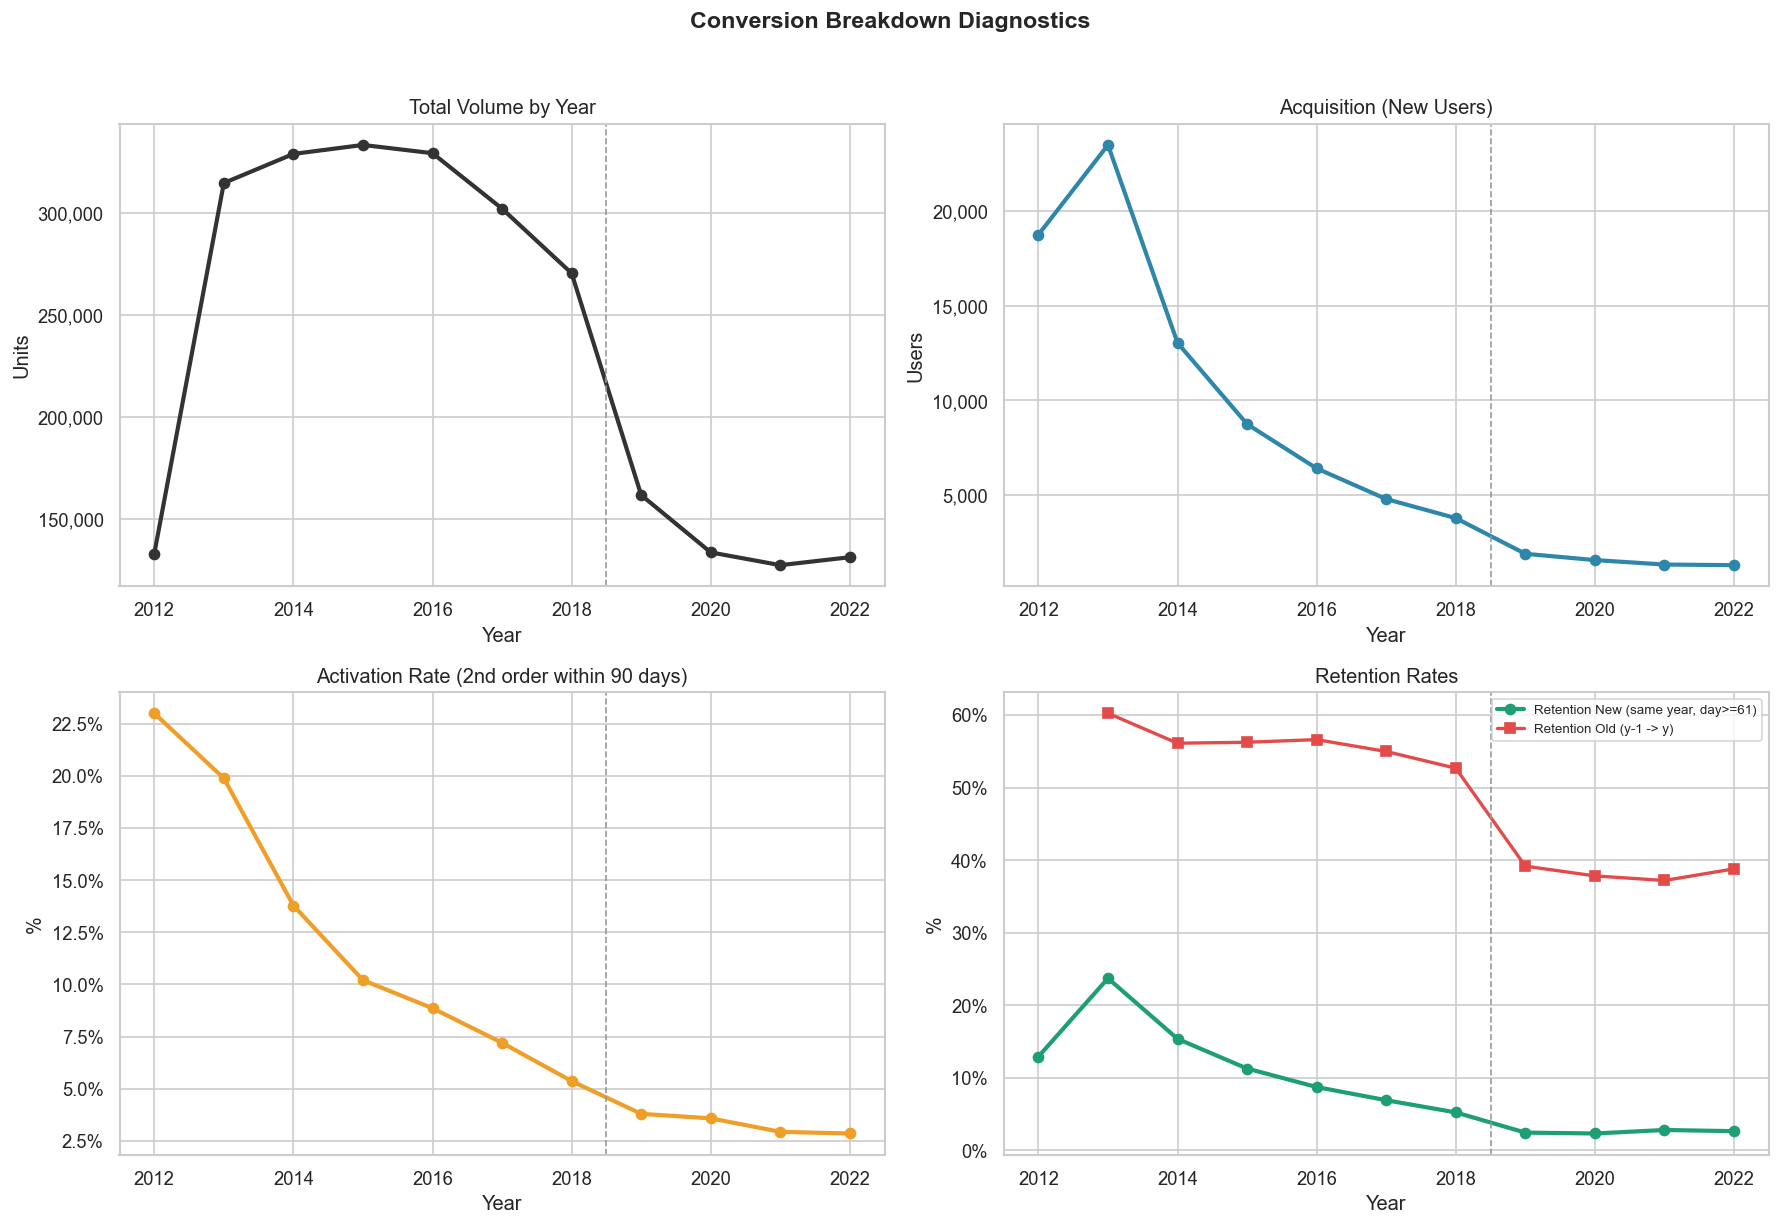

In [5]:
# ---------- 5) Visualize trends ----------
sns.set_style('whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Volume
ax = axes[0, 0]
ax.plot(kpi['year'], kpi['total_qty'], marker='o', linewidth=2.5, color='#333333')
ax.set_title('Total Volume by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Units')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))

# Acquisition
ax = axes[0, 1]
ax.plot(kpi['year'], kpi['acquisition'], marker='o', linewidth=2.5, color='#2E86AB')
ax.set_title('Acquisition (New Users)')
ax.set_xlabel('Year')
ax.set_ylabel('Users')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))

# Activation (new)
ax = axes[1, 0]
ax.plot(kpi['year'], kpi['activation_rate'], marker='o', linewidth=2.5, color='#EF9F27')
ax.set_title('Activation Rate (2nd order within 90 days)')
ax.set_xlabel('Year')
ax.set_ylabel('%')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

# Retention (new + old)
ax = axes[1, 1]
ax.plot(kpi['year'], kpi['retention_new_rate'], marker='o', linewidth=2.5, color='#1D9E75', label='Retention New (same year, day>=61)')
ax.plot(kpi['year'], kpi['retention_old_rate'], marker='s', linewidth=2.0, color='#E24B4A', label='Retention Old (y-1 -> y)')
ax.set_title('Retention Rates')
ax.set_xlabel('Year')
ax.set_ylabel('%')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=8)

for r in range(2):
    for c in range(2):
        axes[r, c].axvline(2018.5, color='#999', linestyle='--', linewidth=1)

fig.suptitle('Conversion Breakdown Diagnostics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

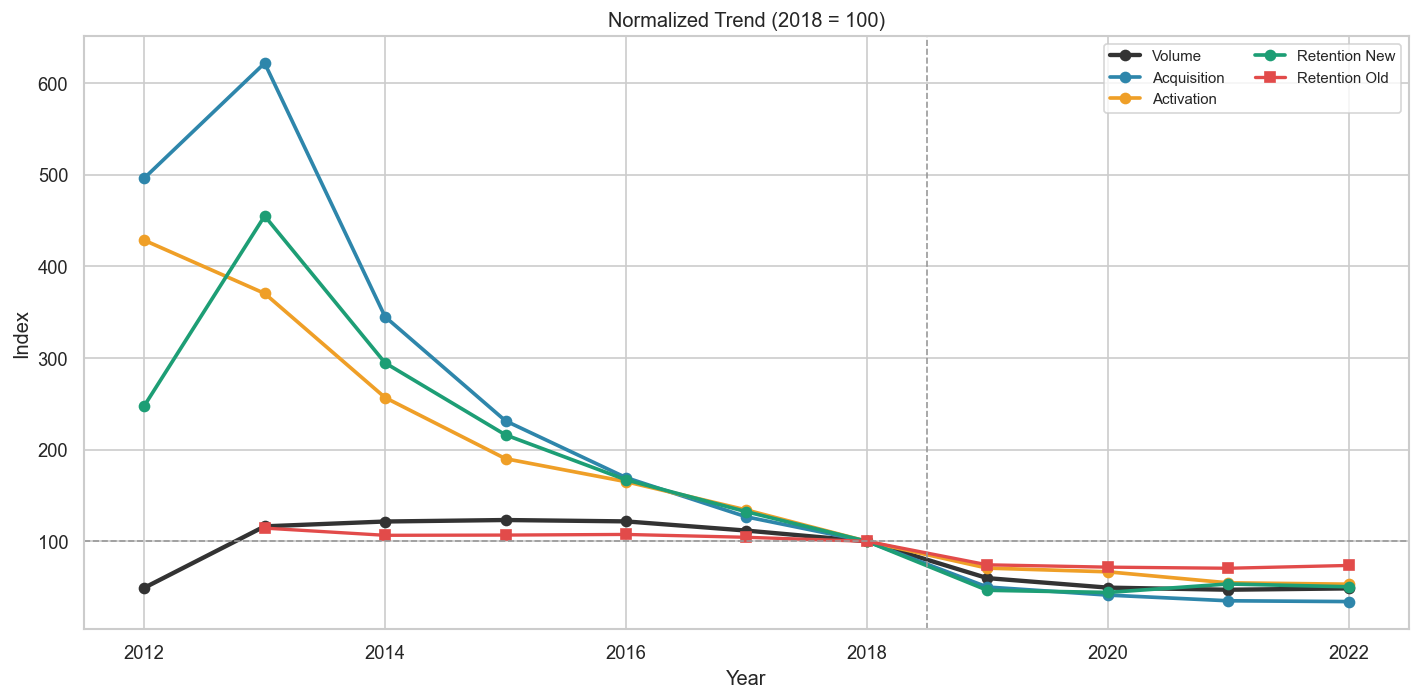

In [6]:
# ---------- 6) Normalized index (base 2018 = 100) for easier comparison ----------
idx = kpi.copy()
base_year = 2018
base = idx[idx['year'] == base_year]

if len(base) == 1:
    b = base.iloc[0]
    idx['volume_idx_2018_100'] = idx['total_qty'] / b['total_qty'] * 100
    idx['acq_idx_2018_100'] = idx['acquisition'] / b['acquisition'] * 100
    idx['act_idx_2018_100'] = idx['activation_rate'] / b['activation_rate'] * 100
    idx['ret_new_idx_2018_100'] = idx['retention_new_rate'] / b['retention_new_rate'] * 100
    idx['ret_old_idx_2018_100'] = idx['retention_old_rate'] / b['retention_old_rate'] * 100

    plt.figure(figsize=(12, 6))
    plt.plot(idx['year'], idx['volume_idx_2018_100'], marker='o', linewidth=2.6, color='#333333', label='Volume')
    plt.plot(idx['year'], idx['acq_idx_2018_100'], marker='o', linewidth=2.2, color='#2E86AB', label='Acquisition')
    plt.plot(idx['year'], idx['act_idx_2018_100'], marker='o', linewidth=2.2, color='#EF9F27', label='Activation')
    plt.plot(idx['year'], idx['ret_new_idx_2018_100'], marker='o', linewidth=2.2, color='#1D9E75', label='Retention New')
    plt.plot(idx['year'], idx['ret_old_idx_2018_100'], marker='s', linewidth=2.0, color='#E24B4A', label='Retention Old')

    plt.axhline(100, color='#999', linestyle='--', linewidth=1)
    plt.axvline(2018.5, color='#999', linestyle='--', linewidth=1)
    plt.title('Normalized Trend (2018 = 100)')
    plt.xlabel('Year')
    plt.ylabel('Index')
    plt.legend(fontsize=9, ncol=2)
    plt.tight_layout()
    plt.show()
else:
    print('Year 2018 not found in data. Skip normalized index plot.')

In [7]:
# ---------- 7) Quick interpretation helper for 2018 -> 2019 ----------
sub = kpi[kpi['year'].isin([2018, 2019])].copy().sort_values('year')
if len(sub) == 2:
    a = sub.iloc[0]
    b = sub.iloc[1]

    def pct_change(new, old):
        if pd.isna(old) or old == 0:
            return np.nan
        return (new - old) / old * 100

    print('--- 2018 -> 2019 change ---')
    print(f"Volume change         : {pct_change(b['total_qty'], a['total_qty']):.2f}%")
    print(f"Acquisition change    : {pct_change(b['acquisition'], a['acquisition']):.2f}%")
    print(f"Activation change     : {pct_change(b['activation_rate'], a['activation_rate']):.2f}%")
    print(f"Retention New change  : {pct_change(b['retention_new_rate'], a['retention_new_rate']):.2f}%")
    print(f"Retention Old change  : {pct_change(b['retention_old_rate'], a['retention_old_rate']):.2f}%")
else:
    print('Need both 2018 and 2019 rows to print change diagnostics.')

--- 2018 -> 2019 change ---
Volume change         : -40.15%
Acquisition change    : -49.88%
Activation change     : -29.23%
Retention New change  : -53.41%
Retention Old change  : -25.64%


In [8]:
# ---------- 8) DETAILED BREAKDOWN: Which variable hurting the most? ----------
# So sánh từng chỉ số để biết cái nào sụt giảm nhiều nhất

years_to_compare = sorted(kpi['year'].dropna().unique())

if len(years_to_compare) >= 2:
    print("=" * 80)
    print("DETAILED BREAKDOWN: Năm nào sụt giảm và kéo xuống cái nào?")
    print("=" * 80)
    
    for i in range(1, len(years_to_compare)):
        prev_year = years_to_compare[i-1]
        curr_year = years_to_compare[i]
        
        prev_row = kpi[kpi['year'] == prev_year].iloc[0]
        curr_row = kpi[kpi['year'] == curr_year].iloc[0]
        
        print(f"\n>>> {int(prev_year)} -> {int(curr_year)} BREAKDOWN:")
        print("-" * 80)
        
        # Tính % change cho từng variable
        changes = {
            'Volume': (curr_row['total_qty'], prev_row['total_qty']),
            'Acquisition': (curr_row['acquisition'], prev_row['acquisition']),
            'Activation Rate %': (curr_row['activation_rate'], prev_row['activation_rate']),
            'Retention New Rate %': (curr_row['retention_new_rate'], prev_row['retention_new_rate']),
            'Retention Old Rate %': (curr_row['retention_old_rate'], prev_row['retention_old_rate'])
        }
        
        results = []
        for var_name, (curr_val, prev_val) in changes.items():
            if pd.isna(curr_val) or pd.isna(prev_val) or prev_val == 0:
                pct_chg = np.nan
            else:
                pct_chg = (curr_val - prev_val) / prev_val * 100
            
            results.append({
                'Variable': var_name,
                f'{int(prev_year)}': f'{prev_val:,.1f}',
                f'{int(curr_year)}': f'{curr_val:,.1f}',
                'Change %': pct_chg
            })
        
        df_change = pd.DataFrame(results)
        df_change = df_change.sort_values('Change %')
        
        print(df_change.to_string(index=False))
        print("\n→ Biến SỤT GIẢM NHẤT:", 
              df_change.iloc[0]['Variable'], 
              f"({df_change.iloc[0]['Change %']:.2f}%)")
        print("→ Biến TĂNG NHẤT (hoặc SỤT ÍT NHẤT):", 
              df_change.iloc[-1]['Variable'], 
              f"({df_change.iloc[-1]['Change %']:.2f}%)")


DETAILED BREAKDOWN: Năm nào sụt giảm và kéo xuống cái nào?

>>> 2012 -> 2013 BREAKDOWN:
--------------------------------------------------------------------------------
            Variable      2012      2013   Change %
   Activation Rate %      23.0      19.9 -13.547847
         Acquisition  18,759.0  23,504.0  25.294525
Retention New Rate %      12.9      23.7  83.656487
              Volume 133,167.0 314,571.0 136.222938
Retention Old Rate %       nan      60.2        NaN

→ Biến SỤT GIẢM NHẤT: Activation Rate % (-13.55%)
→ Biến TĂNG NHẤT (hoặc SỤT ÍT NHẤT): Retention Old Rate % (nan%)

>>> 2013 -> 2014 BREAKDOWN:
--------------------------------------------------------------------------------
            Variable      2013      2014   Change %
         Acquisition  23,504.0  13,043.0 -44.507318
Retention New Rate %      23.7      15.3 -35.241736
   Activation Rate %      19.9      13.8 -30.678929
Retention Old Rate %      60.2      56.1  -6.848158
              Volume 314,571.0 32


ALTERNATIVE DEFINITION: Signup Year + First Order = Activation

alt_acquisition (all first-time customers by signup year):
 year  alt_acquisition
 2012            18759
 2013            23504
 2014            13043
 2015             8749
 2016             6409
 2017             4789
 2018             3781
 2019             1895
 2020             1563
 2021             1328
 2022             1295

alt_activation_rate (100% because definition = first order exists):
 year  alt_activation_rate
 2012                100.0
 2013                100.0
 2014                100.0
 2015                100.0
 2016                100.0
 2017                100.0
 2018                100.0
 2019                100.0
 2020                100.0
 2021                100.0
 2022                100.0


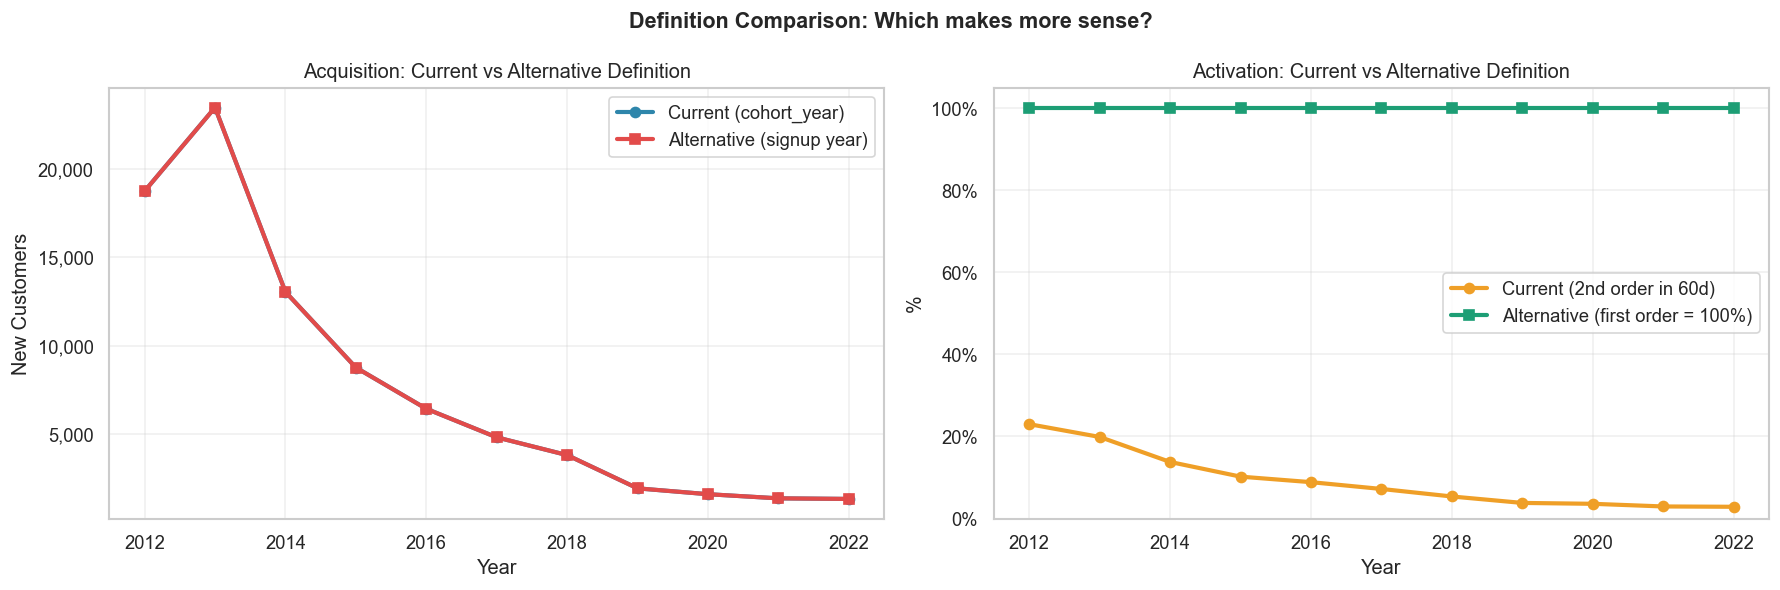


SIDE-BY-SIDE COMPARISON
 year  acq_current  act_current  alt_acquisition  alt_activation_rate
 2012        18759    23.002292            18759                100.0
 2013        23504    19.885977            23504                100.0
 2014        13043    13.785172            13043                100.0
 2015         8749    10.206881             8749                100.0
 2016         6409     8.862537             6409                100.0
 2017         4789     7.204009             4789                100.0
 2018         3781     5.368950             3781                100.0
 2019         1895     3.799472             1895                100.0
 2020         1563     3.582853             1563                100.0
 2021         1328     2.936747             1328                100.0
 2022         1295     2.857143             1295                100.0


In [9]:
# ---------- 9) ALTERNATIVE DEFINITION: Signup Year + First Order Activation ----------
# Thử công thức khác để so sánh

# Acquisition: COUNT khách theo năm của đơn ĐẦUTIÊN (order_date, không là cohort_year)
alt_acq = (
    cust_life[['customer_id', 'signup_date_clean']]
    .assign(signup_year=lambda x: x['signup_date_clean'].dt.year)
    .groupby('signup_year')['customer_id']
    .nunique()
    .reset_index()
    .rename(columns={'signup_year': 'year', 'customer_id': 'alt_acquisition'})
)

# Activation: % khách có đơn đầu tiên (basically 100% vì tất cả trong cust_life đều có)
alt_activation_base = alt_acq.copy()
alt_activation_base['alt_activation_count'] = alt_activation_base['alt_acquisition']  # Tất cả đều "activated"
alt_activation_base['alt_activation_rate'] = 100.0  # 100% vì định nghĩa này là có đơn đầu tiên

print("\n" + "="*80)
print("ALTERNATIVE DEFINITION: Signup Year + First Order = Activation")
print("="*80)
print("\nalt_acquisition (all first-time customers by signup year):")
print(alt_acq.to_string(index=False))
print("\nalt_activation_rate (100% because definition = first order exists):")
print(alt_activation_base[['year', 'alt_activation_rate']].to_string(index=False))

# Vẽ so sánh
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Compare Acquisition
ax = axes[0]
ax.plot(kpi['year'], kpi['acquisition'], marker='o', linewidth=2.5, label='Current (cohort_year)', color='#2E86AB')
ax.plot(alt_acq['year'], alt_acq['alt_acquisition'], marker='s', linewidth=2.5, label='Alternative (signup year)', color='#E24B4A')
ax.set_title('Acquisition: Current vs Alternative Definition')
ax.set_xlabel('Year')
ax.set_ylabel('New Customers')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.legend()
ax.grid(True, alpha=0.3)

# Compare Activation
ax = axes[1]
ax.plot(kpi['year'], kpi['activation_rate'], marker='o', linewidth=2.5, label='Current (2nd order in 60d)', color='#EF9F27')
ax.plot(alt_activation_base['year'], alt_activation_base['alt_activation_rate'], marker='s', linewidth=2.5, label='Alternative (first order = 100%)', color='#1D9E75')
ax.set_title('Activation: Current vs Alternative Definition')
ax.set_xlabel('Year')
ax.set_ylabel('%')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylim([0, 105])
ax.legend()
ax.grid(True, alpha=0.3)

fig.suptitle('Definition Comparison: Which makes more sense?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Merge and show both side-by-side
comparison = (
    kpi[['year', 'acquisition', 'activation_rate']]
    .rename(columns={'acquisition': 'acq_current', 'activation_rate': 'act_current'})
    .merge(alt_acq, on='year', how='outer')
    .merge(alt_activation_base[['year', 'alt_activation_rate']], on='year', how='outer')
    .sort_values('year')
)

print("\n" + "="*80)
print("SIDE-BY-SIDE COMPARISON")
print("="*80)
print(comparison.to_string(index=False))



PROMOTION USAGE SUMMARY
Overall first-order promo rate: 31.19%
Overall second-order-within-90d promo rate: 28.06%


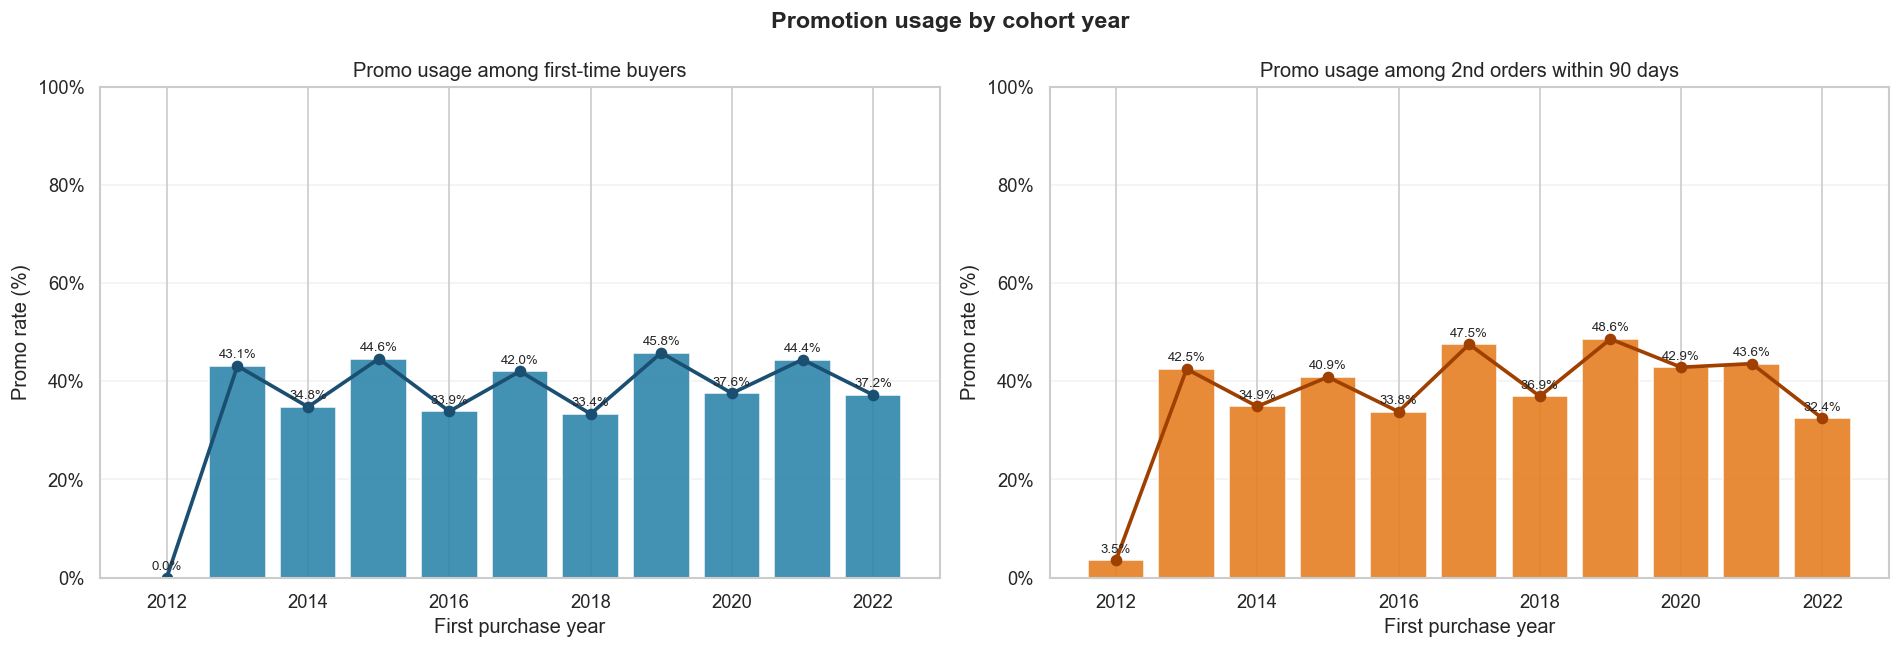


Yearly comparison:
 year  first_order_users  first_order_promo_rate  second_90d_users second_90d_promo_rate
 2012              18759                    0.00              4315              3.499421
 2013              23504                   43.13              4674             42.490372
 2014              13043                   34.78              1798              34.87208
 2015               8749                   44.58               893              40.87346
 2016               6409                   33.87               568             33.802817
 2017               4789                   42.03               345             47.536232
 2018               3781                   33.35               203             36.945813
 2019               1895                   45.80                72             48.611111
 2020               1563                   37.56                56             42.857143
 2021               1328                   44.43                39             43.589744
 

In [10]:
# ---------- 10) PROMOTION VISUALS: first order vs second order within 90 days ----------
# Mục tiêu:
# 1) Trong số người mua lần đầu, bao nhiêu % có dùng promotion để chốt?
# 2) Trong số người mua lần thứ 2 trong vòng 90 ngày, bao nhiêu % có dùng promotion?

# Build an order-level promo flag from order_items
order_promo = (
    order_items.assign(
        promo_line_used=(
            order_items['discount_amount'].fillna(0).gt(0)
            | order_items['promo_id'].notna()
            | order_items['promo_id_2'].notna()
        )
    )
    .groupby('order_id', as_index=False)['promo_line_used']
    .any()
    .rename(columns={'promo_line_used': 'order_promo_used'})
)

# Attach promo flag to the lifecycle table of delivered orders
orders_life = orders_c.merge(order_promo, on='order_id', how='left')
orders_life['order_promo_used'] = orders_life['order_promo_used'].fillna(False)

# First order by customer
first_orders_promo = orders_life[orders_life['order_rank'] == 1][['customer_id', 'order_date', 'year', 'order_promo_used']].copy()
first_orders_promo = first_orders_promo.rename(columns={
    'order_date': 'first_order_date',
    'year': 'cohort_year',
    'order_promo_used': 'first_order_promo_used'
})

# Second order by customer
second_orders_promo = orders_life[orders_life['order_rank'] == 2][['customer_id', 'order_date', 'year', 'order_promo_used']].copy()
second_orders_promo = second_orders_promo.rename(columns={
    'order_date': 'second_order_date',
    'year': 'second_order_year',
    'order_promo_used': 'second_order_promo_used'
})

# Link first and second order to compute 90-day window
promo_life = first_orders_promo[['customer_id', 'cohort_year', 'first_order_date', 'first_order_promo_used']].merge(
    second_orders_promo[['customer_id', 'second_order_date', 'second_order_promo_used']],
    on='customer_id',
    how='left'
)
promo_life['days_to_second_order'] = (promo_life['second_order_date'] - promo_life['first_order_date']).dt.days
promo_life['second_order_within_90d'] = promo_life['days_to_second_order'].between(1, 90, inclusive='both')

# 1) First-order promo usage rate by cohort year
first_order_yearly = (
    promo_life
    .groupby('cohort_year', as_index=False)
    .agg(
        first_order_users=('customer_id', 'nunique'),
        first_order_promo_users=('first_order_promo_used', 'sum')
    )
    .rename(columns={'cohort_year': 'year'})
)
first_order_yearly['first_order_promo_rate'] = np.where(
    first_order_yearly['first_order_users'] > 0,
    first_order_yearly['first_order_promo_users'] / first_order_yearly['first_order_users'] * 100,
    np.nan
)

# 2) Second-order promo usage rate among those who repurchased within 90 days
second_90d_yearly = (
    promo_life[promo_life['second_order_within_90d']]
    .groupby('cohort_year', as_index=False)
    .agg(
        second_90d_users=('customer_id', 'nunique'),
        second_90d_promo_users=('second_order_promo_used', 'sum')
    )
    .rename(columns={'cohort_year': 'year'})
)
second_90d_yearly['second_90d_promo_rate'] = np.where(
    second_90d_yearly['second_90d_users'] > 0,
    second_90d_yearly['second_90d_promo_users'] / second_90d_yearly['second_90d_users'] * 100,
    np.nan
)

# Print quick summary for the full period
print('\n' + '=' * 90)
print('PROMOTION USAGE SUMMARY')
print('=' * 90)
print(f"Overall first-order promo rate: {first_order_yearly['first_order_promo_users'].sum() / first_order_yearly['first_order_users'].sum() * 100:.2f}%")
if second_90d_yearly['second_90d_users'].sum() > 0:
    print(f"Overall second-order-within-90d promo rate: {second_90d_yearly['second_90d_promo_users'].sum() / second_90d_yearly['second_90d_users'].sum() * 100:.2f}%")
else:
    print('Overall second-order-within-90d promo rate: no valid second-order-within-90d users found')

# Two visualizations side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# Chart 1: first order promo rate
ax = axes[0]
ax.bar(first_order_yearly['year'], first_order_yearly['first_order_promo_rate'], color='#2E86AB', alpha=0.9)
ax.plot(first_order_yearly['year'], first_order_yearly['first_order_promo_rate'], color='#1B4F72', linewidth=2.2, marker='o')
ax.set_title('Promo usage among first-time buyers')
ax.set_xlabel('First purchase year')
ax.set_ylabel('Promo rate (%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylim(0, max(100, first_order_yearly['first_order_promo_rate'].max() * 1.15))
ax.grid(True, axis='y', alpha=0.25)

for x, y in zip(first_order_yearly['year'], first_order_yearly['first_order_promo_rate']):
    ax.text(x, y + 1, f'{y:.1f}%', ha='center', va='bottom', fontsize=8)

# Chart 2: second order within 90 days promo rate
ax = axes[1]
ax.bar(second_90d_yearly['year'], second_90d_yearly['second_90d_promo_rate'], color='#E67E22', alpha=0.9)
ax.plot(second_90d_yearly['year'], second_90d_yearly['second_90d_promo_rate'], color='#A04000', linewidth=2.2, marker='o')
ax.set_title('Promo usage among 2nd orders within 90 days')
ax.set_xlabel('First purchase year')
ax.set_ylabel('Promo rate (%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylim(0, max(100, second_90d_yearly['second_90d_promo_rate'].max() * 1.15))
ax.grid(True, axis='y', alpha=0.25)

for x, y in zip(second_90d_yearly['year'], second_90d_yearly['second_90d_promo_rate']):
    ax.text(x, y + 1, f'{y:.1f}%', ha='center', va='bottom', fontsize=8)

fig.suptitle('Promotion usage by cohort year', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Optional: compact comparison table
promo_compare = first_order_yearly[['year', 'first_order_users', 'first_order_promo_rate']].merge(
    second_90d_yearly[['year', 'second_90d_users', 'second_90d_promo_rate']],
    on='year',
    how='outer'
).sort_values('year')

print('\nYearly comparison:')
print(promo_compare.round(2).to_string(index=False))
